In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv('Dataset_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [60]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [61]:
df.drop(['customerID'],axis=1,inplace=True)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [63]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'],errors='coerce')

In [64]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [65]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [66]:
k = df['StreamingMovies'].value_counts()
print(k)

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


In [67]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


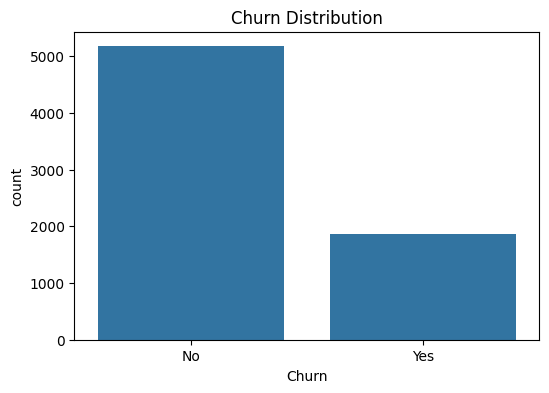

In [68]:
# Check churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title("Churn Distribution")
plt.show()

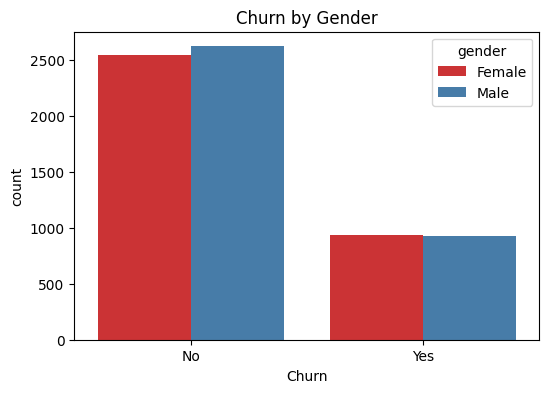

In [69]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='gender', palette='Set1')
plt.title("Churn by Gender")
plt.show()

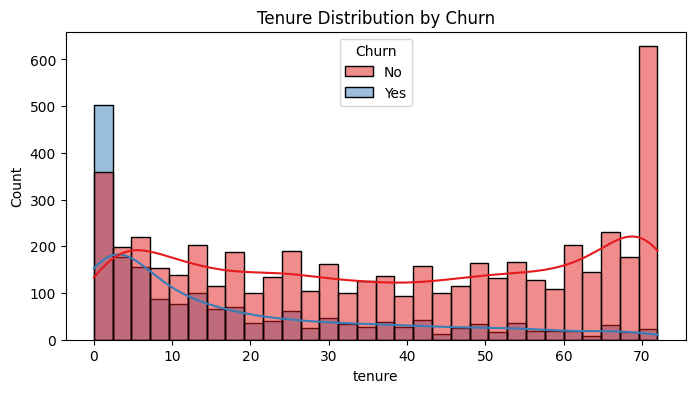

In [70]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette='Set1')
plt.title("Tenure Distribution by Churn")
plt.show()

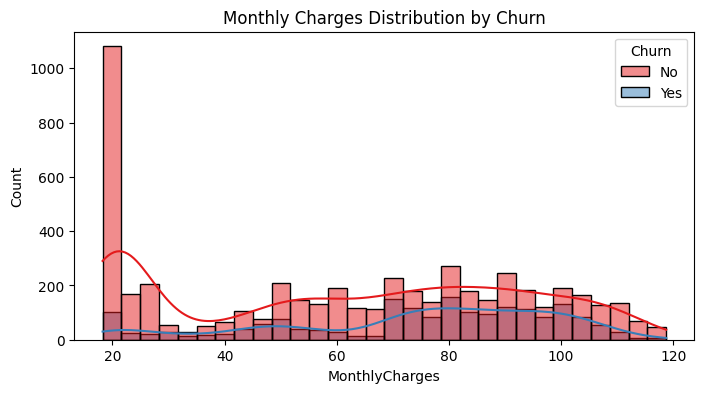

In [71]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, palette='Set1')
plt.title("Monthly Charges Distribution by Churn")
plt.show()

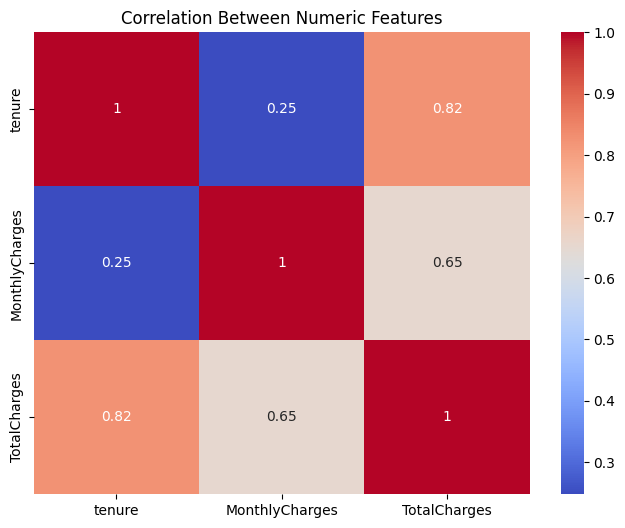

In [72]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Features")
plt.show()

In [73]:
df = pd.get_dummies(df,drop_first=True)

In [74]:
x = df.iloc[:,:-1]
y = df['Churn_Yes']

In [75]:
(y.value_counts()/len(y))*100

Churn_Yes
False    73.463013
True     26.536987
Name: count, dtype: float64

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [77]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [78]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# Logistic Regression



In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
acc = classification_report(y_test,y_pred)
print(acc)

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



bagging

In [80]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(estimator=LogisticRegression(),n_estimators=100,random_state=42,max_samples=0.5,bootstrap=True)
bag.fit(x_train,y_train)
y_pred = bag.predict(x_test)
acc11 = accuracy_score(y_test,y_pred)
print(acc11)

0.8218594748048261


boosting ada

In [81]:
from sklearn.ensemble import AdaBoostClassifier
boost = AdaBoostClassifier(estimator=LogisticRegression(),n_estimators=100,random_state=42)
boost.fit(x_train,y_train)
y_pred = boost.predict(x_test)
acc12 = accuracy_score(y_test,y_pred)
print(acc12)

0.7899219304471257


# KNN

In [82]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model2 = KNeighborsClassifier()
model2.fit(x_train,y_train)
y_pred = model2.predict(x_test)
acc2 = accuracy_score(y_test,y_pred)
print(acc2)

0.7714691270404542


bagging

In [83]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(estimator=KNeighborsClassifier(),n_estimators=100,random_state=42,max_samples=0.5,bootstrap=True)
bag.fit(x_train,y_train)
y_pred = bag.predict(x_test)
acc21 = accuracy_score(y_test,y_pred)
print(acc21)

0.7977288857345636


# Decision Tree

In [84]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model3 = DecisionTreeClassifier()
model3.fit(x_train,y_train)
y_pred = model3.predict(x_test)
acc3 = accuracy_score(y_test,y_pred)
print(acc3)

0.7182398864442867


bagging

In [85]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,random_state=42,max_samples=0.5,bootstrap=True)
bag.fit(x_train,y_train)
y_pred = bag.predict(x_test)
acc31 = accuracy_score(y_test,y_pred)
print(acc31)

0.7934705464868701


# Random Forest

In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model4 = RandomForestClassifier()
model4.fit(x_train,y_train)
y_pred = model4.predict(x_test)
acc4 = accuracy_score(y_test,y_pred)
print(acc4)

0.7920511000709723


bagging

In [88]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(estimator=RandomForestClassifier(),n_estimators=100,random_state=42,max_samples=0.5,bootstrap=True)
bag.fit(x_train,y_train)
y_pred = bag.predict(x_test)
acc41 = accuracy_score(y_test,y_pred)
print(acc41)


0.8105039034776437


# Boosting

In [89]:
from xgboost import XGBClassifier
boost = XGBClassifier(n_estimators=100,max_depth=4,learning_rate=0.1,random_state=42)
boost.fit(x_train,y_train)
y_pred = boost.predict(x_test)
acc42 = accuracy_score(y_test,y_pred)
print(acc42)

0.8126330731014905


Hyperparameter Optimazation

In [90]:
# For Logistic Regression
from sklearn.model_selection import RandomizedSearchCV
dual = [True,False]
max_iter = [100,110,120,130,140]
tol = [0.0001,0.00001,0.000001]
c = [0.2,0.5,1]

grid = {'dual':dual,'max_iter':max_iter,'tol':tol,'C':c}

In [91]:
rf= LogisticRegression()
rf_random1 = RandomizedSearchCV(rf,grid,n_iter=100,cv=3,verbose=2,random_state=42,n_jobs=-1)
rf_random1.fit(x_train,y_train)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 90 is smaller than n_iter=100. Running 90 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 90 candidates, totalling 270 fits


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
135 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
135 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\HP\AppData\Local\P

,estimator,LogisticRegression()
,param_distributions,"{'C': [0.2, 0.5, ...], 'dual': [True, False], 'max_iter': [100, 110, ...], 'tol': [0.0001, 1e-05, ...]}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [92]:
y_pred9 = rf_random1.predict(x_test)
acc5 = classification_report(y_test,y_pred9)
print(acc5)

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [93]:
criterion = ['gini','entropy']
max_depth=[1,10,50]
min_samples_split=[2,10]
min_samples_leaf=[1,5]
max_features=['auto','sqrt','log2']

grid2 = {'criterion':criterion,
         'max_depth':max_depth,
         'min_samples_split':min_samples_split,
         'min_samples_leaf':min_samples_leaf,
         'max_features':max_features}

In [94]:
hi = DecisionTreeClassifier()
bi = RandomizedSearchCV(hi,grid2,n_iter=100,cv=3,random_state=42,n_jobs=-1)
bi.fit(x_train,y_train)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 72 is smaller than n_iter=100. Running 72 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
72 fits failed out of a total of 216.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
52 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **

,estimator,DecisionTreeClassifier()
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [1, 10, ...], 'max_features': ['auto', 'sqrt', ...], 'min_samples_leaf': [1, 5], ...}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [95]:
pred = bi.predict(x_test)
acc6 = accuracy_score(y_test,pred)
print(acc6)

0.7955997161107168


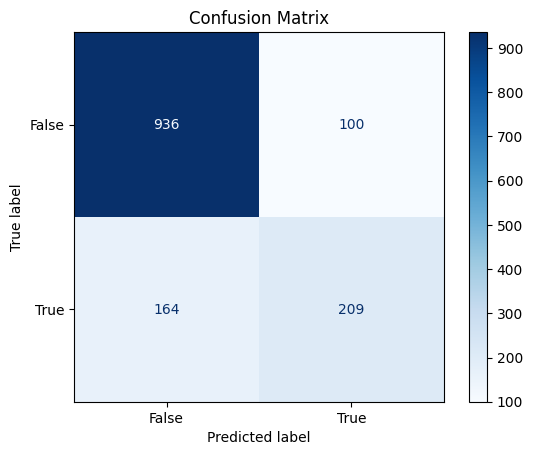

In [96]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

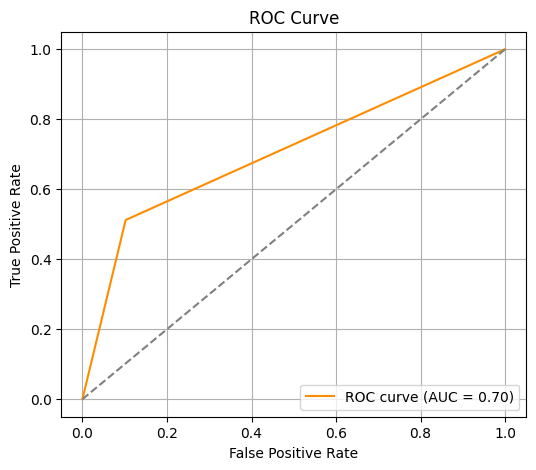

In [97]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [99]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,r2_score

# Applying The PCA

In [100]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
x_train_new = pca.fit_transform(x_train)
x_test_new = pca.transform(x_test)

In [101]:
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[0.33206693 0.12010562 0.08998675 0.04719646 0.04156419]


In [102]:
model2 = LogisticRegression()
model2.fit(x_train_new,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [103]:
y_pred_new = model2.predict(x_test_new)
acc2 = round(accuracy_score(y_test,y_pred_new)*100,2)
print(acc2)

80.77


# Applying The LDA

In [104]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA()
x_train_lda = lda.fit_transform(x_train,y_train)
x_test_lda = lda.transform(x_test)

In [105]:
var = lda.explained_variance_ratio_
var

array([1.])

In [106]:
model3 = LogisticRegression()
model3.fit(x_train_lda,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [107]:
y_pred_lda = model3.predict(x_test_lda)
acc3 = round(accuracy_score(y_test,y_pred_lda)*100,2)
print(acc3)

82.04


# Now Applying Kernel PCA

In [109]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(n_components=5)
x_train_kpca = kpca.fit_transform(x_train)
x_test_kpca = kpca.transform(x_test)

In [110]:
model4 = LogisticRegression()
model4.fit(x_train_kpca,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [111]:
y_pred_kpca = model4.predict(x_test_kpca)
acc4 = round(accuracy_score(y_test,y_pred_kpca)*100,2)
print(acc4)

80.77


# Applying QDA

In [112]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
qda = QDA()
x_train_qda = qda.fit(x_train,y_train)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [113]:
y_pred_qda = x_train_qda.predict(x_test)
acc5 = round(accuracy_score(y_test,y_pred_qda)*100,2)
print(acc5)

69.84
